Выборка для тренировки лежит https://titan.gml-team.ru:5003/sharing/yX8enupJV

Данные о каждом видео лежат в файле *train_dataset\info.json*. Это список из словарей, каждый словарь содержит информацию о расположении видео, о расположении ответов на смены сцен и содержит длину видео

In [ ]:
import sys, subprocess, pkgutil

def ensure(pip_name, import_name=None):
    import_name = import_name or pip_name
    if pkgutil.find_loader(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", pip_name])

# Обычно в Colab это уже есть, но пусть будет надёжно:
ensure("tqdm")
ensure("seaborn")
ensure("pandas")
ensure("scikit-learn")
# cv2 обычно есть; если вдруг нет:
if pkgutil.find_loader("cv2") is None:
    ensure("opencv-python-headless", "cv2")

/tmp/ipykernel_505/4277555641.py:5: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader(import_name) is None:
/tmp/ipykernel_505/4277555641.py:14: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("cv2") is None:


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import zipfile
import shutil
import re
from pathlib import Path

# УКАЖИ СВОЙ ZIP-ФАЙЛ
ZIP_PATH = Path("/content/drive/MyDrive/CMC_1/public_tests.zip")

RAW_DIR = Path("/content/_raw_dataset")
TRAIN_DIR = Path("/content/train_dataset")

assert ZIP_PATH.exists(), f"Не найден архив: {ZIP_PATH}"

# Чистим старые папки
if RAW_DIR.exists():
    shutil.rmtree(RAW_DIR)
if TRAIN_DIR.exists():
    shutil.rmtree(TRAIN_DIR)

RAW_DIR.mkdir(parents=True, exist_ok=True)

# Распаковываем архив
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(RAW_DIR)

def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f, strict=False)

# Сценарий 1: внутри архива уже есть готовый train_dataset
ready_train_dirs = [p.parent for p in RAW_DIR.rglob("info.json") if p.parent.name == "train_dataset"]

if ready_train_dirs:
    src_train = ready_train_dirs[0]
    shutil.copytree(src_train, TRAIN_DIR)
    print("✅ Найден готовый train_dataset внутри архива")
else:
    # Сценарий 2: архив состоит из папок вида 00_test_file_input, 01_test_file_input, ...
    case_dirs = sorted([
        p for p in RAW_DIR.rglob("*")
        if p.is_dir() and re.match(r"^\d+_test_file_input$", p.name)
    ])

    assert case_dirs, "Не найден ни готовый train_dataset, ни папки *_test_file_input"

    (TRAIN_DIR / "video").mkdir(parents=True, exist_ok=True)
    (TRAIN_DIR / "gt").mkdir(parents=True, exist_ok=True)

    def resolve_video_and_gt(case_input_dir: Path, case_id: str):
        info_path = case_input_dir / "info.json"
        assert info_path.exists(), f"Нет info.json в {case_input_dir}"

        info = load_json(info_path)
        if isinstance(info, dict):
            info = [info]
        assert len(info) > 0, f"Пустой info.json в {case_input_dir}"

        rec = info[0]

        src_rel = rec.get("source")
        sc_rel = rec.get("scene_change") or rec.get("gt")

        video_path = (case_input_dir / src_rel) if src_rel else None
        if video_path is None or not video_path.exists():
            videos = sorted((case_input_dir / "video").glob("*.mp4"))
            assert videos, f"Не найден mp4 в {case_input_dir / 'video'}"
            video_path = videos[0]

        gt_path = (case_input_dir / sc_rel) if sc_rel else None
        if gt_path is None or not gt_path.exists():
            gts = sorted((case_input_dir / "gt").glob("*.json"))
            if gts:
                gt_path = gts[0]
            else:
                sibling_gt = case_input_dir.parent / f"{case_id}_test_file_gt"
                if sibling_gt.exists():
                    gts2 = sorted(sibling_gt.rglob("*.json"))
                    assert gts2, f"Есть {sibling_gt}, но json не найден"
                    gt_path = gts2[0]
                else:
                    raise FileNotFoundError(
                        f"Не найден gt ни в {case_input_dir / 'gt'}, ни в {sibling_gt}"
                    )

        return video_path, gt_path, rec

    merged_info = []

    for case_dir in case_dirs:
        case_id = case_dir.name.split("_")[0]

        video_src, gt_src, rec = resolve_video_and_gt(case_dir, case_id)

        video_dst = TRAIN_DIR / "video" / f"{case_id}.mp4"
        gt_dst = TRAIN_DIR / "gt" / f"{case_id}.json"

        # Копируем, а не делаем symlink — так надёжнее для Colab
        shutil.copy2(video_src, video_dst)
        shutil.copy2(gt_src, gt_dst)

        new_rec = dict(rec)
        new_rec["source"] = f"video/{case_id}.mp4"
        new_rec["scene_change"] = f"gt/{case_id}.json"
        merged_info.append(new_rec)

    with open(TRAIN_DIR / "info.json", "w", encoding="utf-8") as f:
        json.dump(merged_info, f, ensure_ascii=False, indent=2)

    print("✅ train_dataset собран из *_test_file_input")

print("Папка датасета:", TRAIN_DIR)
print("Видео:", len(list((TRAIN_DIR / "video").glob("*.mp4"))))
print("GT:", len(list((TRAIN_DIR / "gt").glob("*.json"))))

%cd /content

Mounted at /content/drive
✅ train_dataset собран из *_test_file_input
Папка датасета: /content/train_dataset
Видео: 10
GT: 10
/content


In [ ]:
import os
print(os.path.exists("train_dataset/video/03.mp4"), "train_dataset/video/03.mp4")
print(os.path.exists("train_dataset/gt/03.json"), "train_dataset/gt/03.json")

True train_dataset/video/03.mp4
True train_dataset/gt/03.json


In [ ]:
import cv2

def read_video_to_list(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if ret == False:
            break
        frames.append(frame)
    cap.release()
    return frames

In [ ]:
import os, json

info_path = "/content/train_dataset/info.json"
with open(info_path, "r") as f:
    info = json.load(f, strict=False)

print("Видео в info.json:", len(info))
print("Ключи первой записи:", list(info[0].keys()))

src = info[0]["source"]
video_path = os.path.join("/content/train_dataset", src)

frames = read_video_to_list(video_path)

print("Видео:", video_path)
print("Кадров:", len(frames), "shape[0]:", frames[0].shape)

Видео в info.json: 10
Ключи первой записи: ['source', 'scene_change', 'len']
Видео: /content/train_dataset/video/00.mp4
Кадров: 3250 shape[0]: (720, 1280, 3)


In [ ]:
import numpy as np
import cv2 # Для установки opencv воспользуйтесь командой в терминале conda install -c conda-forge opencv
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

In [ ]:
import json
def load_json_from_file(filename):
    with open(filename, "r") as f:
        return json.load(f, strict=False)


def dump_json_to_file(obj, filename, **kwargs):
    with open(filename, "w") as f:
        json.dump(obj, f, **kwargs)

In [ ]:
video_dataset = load_json_from_file('train_dataset/info.json')
video_dataset

[{'source': 'video/00.mp4', 'scene_change': 'gt/00.json', 'len': 3250},
 {'source': 'video/01.mp4', 'scene_change': 'gt/01.json', 'len': 3392},
 {'source': 'video/02.mp4', 'scene_change': 'gt/02.json', 'len': 5662},
 {'source': 'video/03.mp4', 'scene_change': 'gt/03.json', 'len': 3321},
 {'source': 'video/04.mp4', 'scene_change': 'gt/04.json', 'len': 3396},
 {'source': 'video/05.mp4', 'scene_change': 'gt/05.json', 'len': 6096},
 {'source': 'video/06.mp4', 'scene_change': 'gt/06.json', 'len': 2326},
 {'source': 'video/07.mp4', 'scene_change': 'gt/07.json', 'len': 2905},
 {'source': 'video/08.mp4', 'scene_change': 'gt/08.json', 'len': 4898},
 {'source': 'video/09.mp4', 'scene_change': 'gt/09.json', 'len': 7749}]

### Загрузка видео ###

Загрузка видео осуществляется при помощи cv2.VideoCapture. Этот код изменять и дописывать не нужно.

In [ ]:
def read_video(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while(cap.isOpened()):
        ret, frame = cap.read()
        if ret==False:
            break
        yield frame
    cap.release()

In [ ]:
frames = read_video(os.path.join('train_dataset', 'video', '03.mp4'))

Что такое frames? Это итератор на кадры видео. Чтобы пройтись по всем кадрам последовательности, воспользуйтесь следующей конструкцией:
*Аккуратно, по одной переменной frames можно пройти только один раз!*

In [ ]:
for frame in tqdm(frames):
    pass
for frame in tqdm(frames): # Второй раз уже не будет итерации
    pass

0it [00:00, ?it/s]

0it [00:00, ?it/s]

### Пишем свой простой детектор смен сцен

На данном этапе предлагается написать простой Scene Change Detector (SCD) на основе выделения характеристик кадров, подсчёта разницы между кадрами на основе данных характеристик, а также подобрать наиболее оптимальный порог для этих признаков и совместить эти признаки.
Сменой сцен в данной задаче являются только обычные мгновенные смены сцен, без дополнительных эффектов.

В качестве примера приведён простой детектор смен, который считает межкадровую разницу между кадрами.

*Важное замечание. Здесь и далее результатом алгоритма детектора сцен являются **индексы кадров начал сцен**, при этом кадры **нумеруются с 0**. Нулевой кадр в качестве ответа указывать не нужно*

<img src="Hard_cut.jpg">

In [ ]:
def baseline_scene_change_detector(frames, threshold=2000, with_vis=False):
    """
    Baseline SCD

    Arguments:
    frames -- iterator on video frames
    threshold -- parameter of your algorithm (optional)
    with_vis -- saving neighboring frames at a scene change (optional)

    Returns:
    scene_changes -- list of scene changes (idx of frames)
    vis -- list of neighboring frames at a scene change (for visualization)
    metric_values -- list of metric values (for visualization)
    """

    def pixel_metric(frame, prev_frame):
        # Базовое расстояние между кадрами - среднеквадратическая ошибка между ними
        return np.mean((frame.astype(np.int32) - prev_frame) ** 2)

    scene_changes = []
    vis = []
    metric_values = []
    prev_frame = None
    for idx, frame in tqdm(enumerate(frames), leave=False):
        # frame - это кадр
        # idx - это номер кадра
        if prev_frame is not None:
            # Находим расстояние между соседними кадрами
            metric_value = pixel_metric(frame, prev_frame)
            if metric_value > threshold:
                scene_changes.append(idx)
                if with_vis:
                    # Кадры в памяти занимают много места, поэтому сохраним лишь первые 100 срабатываний
                    if len(vis) < 100:
                        vis.append([prev_frame, frame])
            metric_values.append(metric_value)
        else:
            metric_values.append(0)
        prev_frame = frame
    return scene_changes, vis, metric_values

In [ ]:
frames = read_video(os.path.join('train_dataset', 'video', '03.mp4'))
cuts_base = load_json_from_file(os.path.join('train_dataset', 'gt', '03.json'))['cut']
scene_changes_base, vis_base, metric_values_base = baseline_scene_change_detector(frames, with_vis=True)

0it [00:00, ?it/s]

Посмотрим визуально, насколько сильно алгоритм ошибается, а также на значения метрики

In [ ]:
def visualize_metric_error(frame, prev_frame, value):
    fig = plt.figure(figsize=(16,4))
    plt.suptitle('Значение метрики на текущем кадре: {:.4f}'.format(value), fontsize=24)
    ax = fig.add_subplot(1, 2, 1)
    ax.imshow(prev_frame[:,:,::-1])
    ax.set_title("Предыдущий кадр", fontsize=18)
    ax.set_xticks([])
    ax.set_yticks([])
    ax = fig.add_subplot(1, 2, 2)
    ax.imshow(frame[:,:,::-1])
    ax.set_title("Текущий кадр", fontsize=18)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.subplots_adjust(top=0.80)

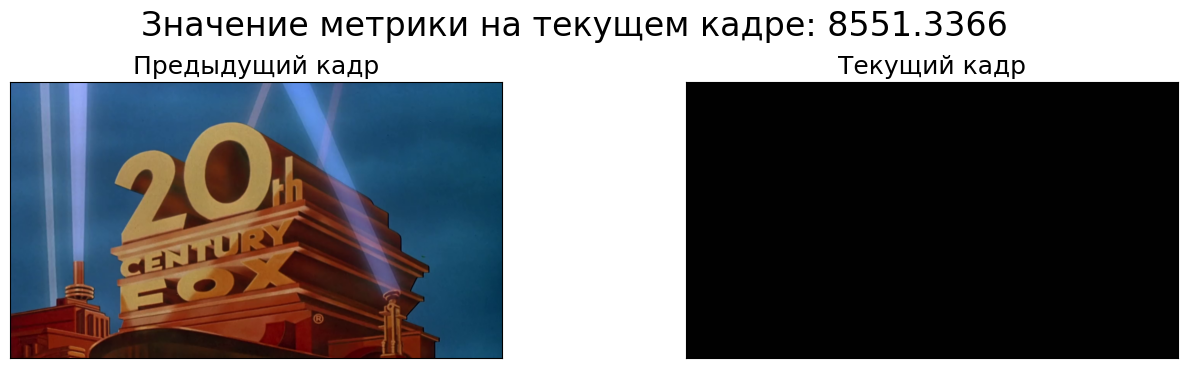

In [ ]:
idx = 1
visualize_metric_error(vis_base[idx][0], vis_base[idx][1], metric_values_base[scene_changes_base[idx]])
# смена сцен

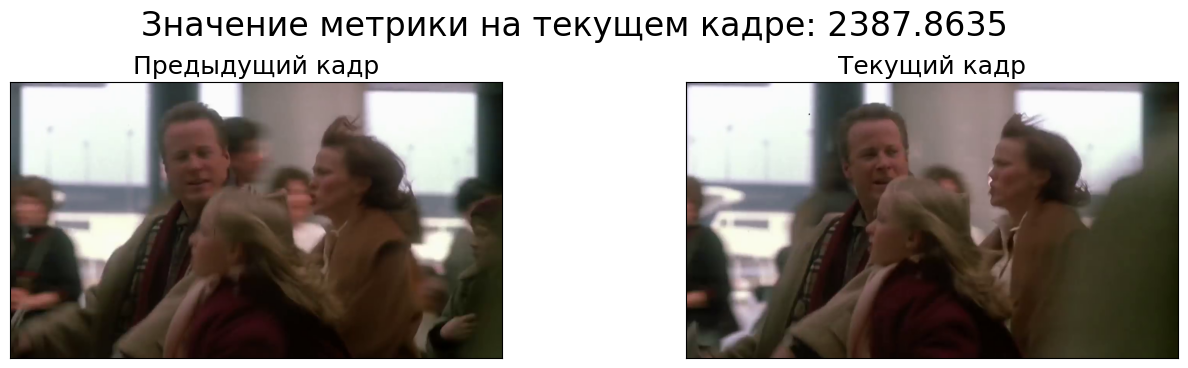

In [ ]:
idx = 10
visualize_metric_error(vis_base[idx][0], vis_base[idx][1], metric_values_base[scene_changes_base[idx]])
# ошибается, это не смена сцен

In [ ]:
def visualize_metric_values(metric_values, threshold, cuts = None):
    sns.set()
    plt.figure(figsize=(16, 8))
    plt.plot(metric_values, label='Значение метрики на кадрах')
    plt.xlabel('Номер кадра')
    plt.ylabel('Значение метрики')
    plt.hlines(y=threshold, xmin=0, xmax=len(metric_values), linewidth=2, color='r', label='Пороговое значение')

    if cuts is not None:
        for cut in cuts:
            plt.axvline(x=cut, color='k', linestyle=':', linewidth=0.5, label='Смена сцены')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.show()

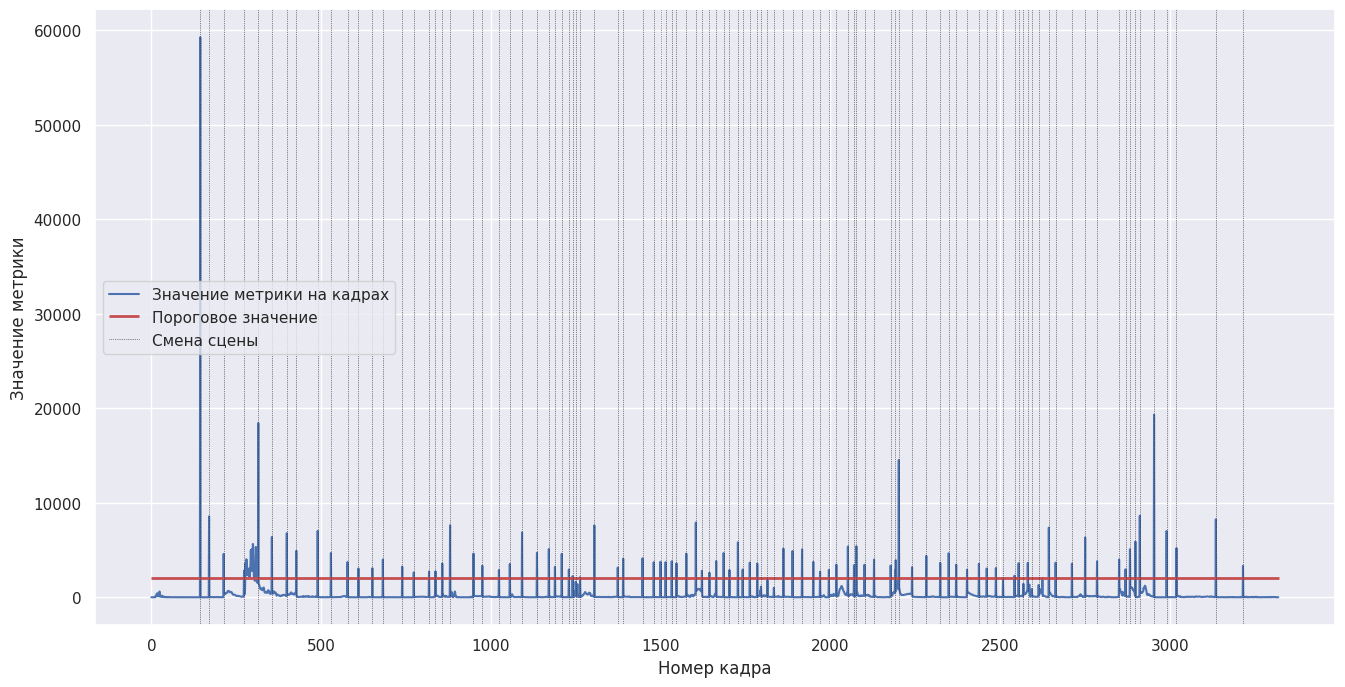

In [ ]:
visualize_metric_values(metric_values_base, 2000, cuts_base)

**Как видим, очень плохо подобран порог, да и сам признак, похоже, сильно зашумлён. Попробуйте что-то своё!**

### Ваше решение

* В качестве решения вы должны прикрепить функцию ниже. Все пороги должны быть указаны внутри функции.  
Т.е. должен быть возможен вызов:  
`scene_changes, vis, metric_values = scene_change_detector(frames)`  
* Строку (# GRADED CELL: [function name]) менять **нельзя**. Она будет использоваться при проверке вашего решения.
* Ячейка должна содержать только **одну** функцию.

In [ ]:
# GRADED CELL: scene_change_detector
def scene_change_detector(frames, with_vis=False):
    threshold = 0.15
    weight_diff = 0.3
    weight_hsv = 0.3
    weight_chrom = 0.4
    weight_mafd = 0.08
    weight_block = 0.02
    fusion_threshold = 0.25
    min_distance = 5
    diff_threshold = 11

    block_grid = 8
    block_mean_threshold = 12.0

    def find_peaks_numpy(signal, height=None, threshold=None, distance=1, prominence=None, global_threshold=None):
        signal = np.asarray(signal)
        candidates = np.where((signal[1:-1] > signal[:-2]) & (signal[1:-1] >= signal[2:]))[0] + 1
        if global_threshold is not None:
            global_threshold = float(global_threshold)
            candidates = candidates[signal[candidates] >= global_threshold]
        if height is not None:
            height = float(height)
            candidates = candidates[signal[candidates] >= height]
        if threshold is not None and candidates.size > 0:
            threshold = float(threshold)
            left_diff = signal[candidates] - signal[candidates - 1]
            right_diff = signal[candidates] - signal[candidates + 1]
            mask = (left_diff >= threshold) & (right_diff >= threshold)
            candidates = candidates[mask]
        if prominence is not None and candidates.size > 0:
            prominence = float(prominence)
            valid_candidates = []
            for idx in candidates:
                left_min = signal[:idx].min() if idx > 0 else signal[idx]
                right_min = signal[idx:].min() if idx < len(signal) else signal[idx]
                prom = signal[idx] - max(left_min, right_min)
                if prom >= prominence:
                    valid_candidates.append(idx)
            candidates = np.array(valid_candidates)
        if distance > 1 and candidates.size > 0:
            distance = int(distance)
            order = np.argsort(signal[candidates])[::-1]
            sorted_peaks = candidates[order]
            keep = np.ones(sorted_peaks.shape, dtype=bool)
            for i in range(sorted_peaks.size):
                if keep[i]:
                    diff = np.abs(sorted_peaks[i] - sorted_peaks)
                    keep[diff < distance] = False
                    keep[i] = True
            candidates = np.sort(sorted_peaks[keep])
        return candidates

    def find_significant_peaks(signal, auto_factor=1.3, auto_prominence_factor=0.4, distance=1,
                               global_threshold=None, threshold=0.15):
        median_val = np.median(signal)
        std_val = np.std(signal)
        auto_height = median_val + auto_factor * std_val
        auto_prominence = auto_prominence_factor * std_val
        return find_peaks_numpy(
            signal,
            height=auto_height,
            threshold=threshold,
            distance=distance,
            prominence=auto_prominence,
            global_threshold=global_threshold
        )

    def compute_block_ratio(prev_gray, curr_gray, grid=8, mean_threshold=12.0):
        h, w = prev_gray.shape
        block_h = max(1, h // grid)
        block_w = max(1, w // grid)

        usable_h = block_h * grid
        usable_w = block_w * grid

        prev_crop = prev_gray[:usable_h, :usable_w].astype(np.float32)
        curr_crop = curr_gray[:usable_h, :usable_w].astype(np.float32)

        prev_blocks = prev_crop.reshape(grid, block_h, grid, block_w).transpose(0, 2, 1, 3)
        curr_blocks = curr_crop.reshape(grid, block_h, grid, block_w).transpose(0, 2, 1, 3)

        prev_means = prev_blocks.mean(axis=(2, 3))
        curr_means = curr_blocks.mean(axis=(2, 3))

        changed_blocks = np.abs(prev_means - curr_means) > mean_threshold
        return float(changed_blocks.mean())

    raw_metrics = {
        'diff': [0.0],
        'hsv': [0.0],
        'chrom': [0.0],
        'mafd': [0.0],
        'block': [0.0],
    }

    previous_frame = None
    prev_gray = None
    prev_hsv = None
    prev_ycrcb = None

    for frame_index, frame in tqdm(enumerate(frames), leave=False):
        is_color = frame.ndim == 3
        if is_color:
            curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            curr_hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            curr_ycrcb = cv2.cvtColor(frame, cv2.COLOR_BGR2YCrCb)
        else:
            curr_gray = frame
            curr_bgr = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
            curr_hsv = cv2.cvtColor(curr_bgr, cv2.COLOR_BGR2HSV)
            curr_ycrcb = cv2.cvtColor(curr_bgr, cv2.COLOR_BGR2YCrCb)

        if previous_frame is None:
            previous_frame = frame
            prev_gray = curr_gray
            prev_hsv = curr_hsv
            prev_ycrcb = curr_ycrcb
            continue

        gray_diff = np.abs(prev_gray.astype(np.int32) - curr_gray.astype(np.int32))

        diff_mask = gray_diff > diff_threshold
        raw_metrics['diff'].append(float(np.count_nonzero(diff_mask) / diff_mask.size))

        mafd = float(gray_diff.mean() / 255.0)
        raw_metrics['mafd'].append(mafd)

        hue_prev = prev_hsv[:, :, 0]
        hue_curr = curr_hsv[:, :, 0]
        hist_prev = np.bincount(hue_prev.ravel(), minlength=180).astype(np.float32)
        hist_curr = np.bincount(hue_curr.ravel(), minlength=180).astype(np.float32)
        hist_prev /= (hist_prev.sum() + 1e-10)
        hist_curr /= (hist_curr.sum() + 1e-10)
        raw_metrics['hsv'].append(float(np.sum(np.abs(hist_prev - hist_curr))))

        if is_color:
            chrom_diff = 0.0
            for ch in [1, 2]:
                hist_prev = np.bincount(prev_ycrcb[:, :, ch].ravel(), minlength=256).astype(np.float32)
                hist_curr = np.bincount(curr_ycrcb[:, :, ch].ravel(), minlength=256).astype(np.float32)
                hist_prev /= (hist_prev.sum() + 1e-10)
                hist_curr /= (hist_curr.sum() + 1e-10)
                chrom_diff += np.sum(np.abs(hist_prev - hist_curr))
            chrom_diff /= 2.0
            raw_metrics['chrom'].append(float(chrom_diff))
        else:
            raw_metrics['chrom'].append(0.0)

        raw_metrics['block'].append(
            compute_block_ratio(
                prev_gray,
                curr_gray,
                grid=block_grid,
                mean_threshold=block_mean_threshold
            )
        )

        previous_frame = frame
        prev_gray = curr_gray
        prev_hsv = curr_hsv
        prev_ycrcb = curr_ycrcb

    normalized_metrics = {}
    for key, values in raw_metrics.items():
        arr = np.array(values)
        normalized_metrics[key] = (arr - arr.min()) / (np.ptp(arr) + 1e-10)

    combined_color_metric = (
        normalized_metrics['hsv'] * weight_hsv +
        normalized_metrics['chrom'] * weight_chrom +
        normalized_metrics['diff'] * weight_diff +
        normalized_metrics['mafd'] * weight_mafd +
        normalized_metrics['block'] * weight_block
    )

    significant_peaks = find_significant_peaks(
        combined_color_metric,
        auto_factor=1.3,
        auto_prominence_factor=0.4,
        distance=min_distance,
        global_threshold=fusion_threshold,
        threshold=threshold
    )
    scene_changes = significant_peaks.tolist()
    metric_values = combined_color_metric.tolist()

    visualization = []
    if with_vis:
        for idx in scene_changes:
            if 0 < idx < len(frames) and len(visualization) < 100:
                visualization.append([frames[idx - 1], frames[idx]])
    return scene_changes, visualization, metric_values

In [ ]:
frames = read_video_to_list(os.path.join('train_dataset', 'video', '03.mp4'))
cuts = load_json_from_file(os.path.join('train_dataset', 'gt', '03.json'))['cut']
scene_changes, vis, metric_values = scene_change_detector(frames, with_vis=True)

0it [00:00, ?it/s]

#### Обратите внимание на скорость работы алгоритма! ####
Если вычислять признаки без циклов по пикселям, а пользоваться методами из numpy, то скорость будет не медленнее 7-8 кадров в секунду.
Например, вы можете использовать функцию `np.histogram` или `cv2.calcHist` для подсчёта гистограмм, а `cv2.Sobel` для применения оператора Собеля к кадру.

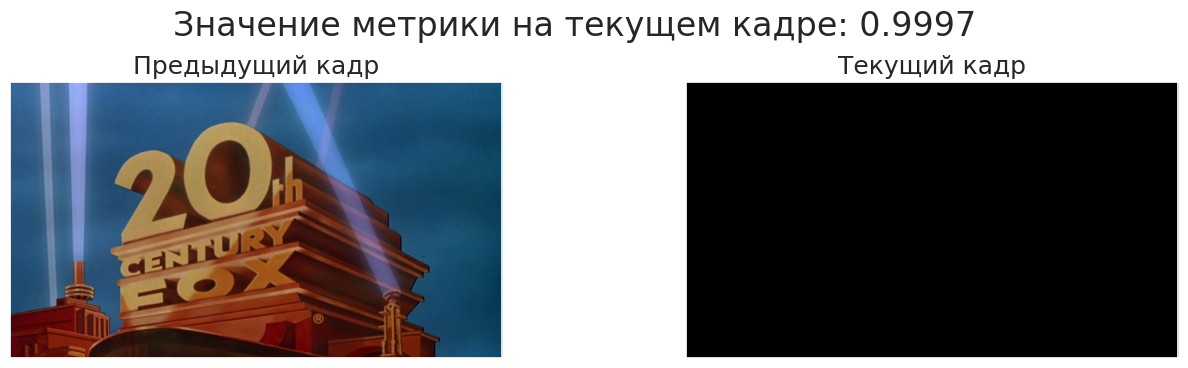

In [ ]:
#Посмотрим на найденные смены сцен
idx = 1
visualize_metric_error(vis[idx][0], vis[idx][1], metric_values[scene_changes[idx]])

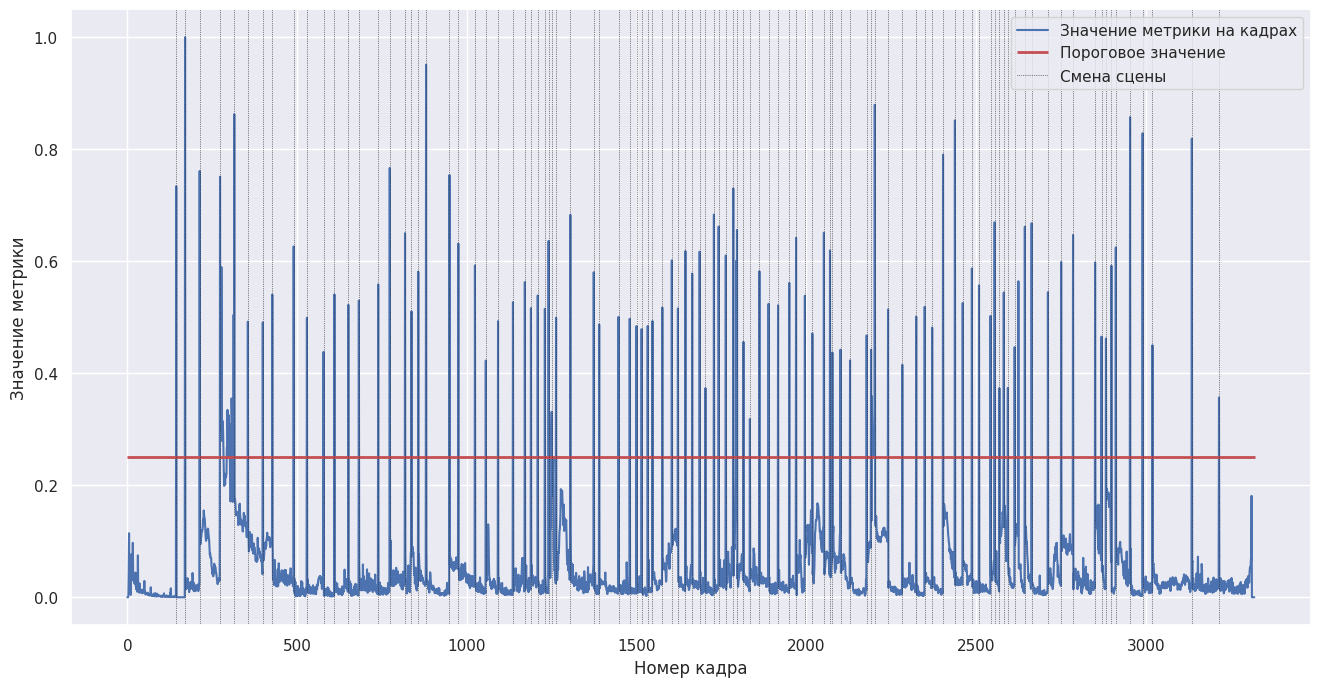

In [ ]:
#Посмотрим на значения метрики
visualize_metric_values(metric_values, 0.25, cuts)

### Подсчёт метрики F1-Score

Чтобы оценивать алгоритм и научиться сравнивать несколько алгоритмов, нужна метрика качества. В данной задаче для оценки качества алгоритма используется F1-Score. Преимущества использования этой метрики к текущей постановке задачи смены сцен были рассказаны на лекции, напишем только формулы:
$$precision = \frac{tp}{tp+fp}$$
$$recall = \frac{tp}{tp+fn}$$
$$F = 2 * \frac{precision * recall}{precision+recall}$$

На всякий случай опишем как именно происходит подсчёт метрики для видео

1) Сначала из выборки удаляются все кадры, которые по разметке либо являются сложными переходами между сценами, либо помечены как сложные для анализа и разметки (например, титры/обилие компьютерной графики и т.п)


2) Затем для оставшихся кадров уже подсчитывается F1_Score

In [ ]:
#Эти пять клеток кода править не нужно
def calculate_matrix(true_scd, predicted_scd, scene_len, not_to_use_frames=set()):
    predicted_scd = set(predicted_scd)
    tp, fp, tn, fn = 0, 0, 0, 0
    scene_len = scene_len
    for scd in predicted_scd:
        if scd in true_scd:
            tp += 1
        elif scd not in not_to_use_frames:
            fp += 1
    for scd in true_scd:
        if scd not in predicted_scd:
            fn += 1
    tn = scene_len - len(not_to_use_frames) - tp - fp - fn
    return tp, fp, tn, fn

In [ ]:
def calculate_precision(tp, fp, tn, fn):
    return tp / max(1, (tp + fp))

In [ ]:
def calculate_recall(tp, fp, tn, fn):
    return tp / max(1, (tp + fn))

In [ ]:
def f1_score(true_scd, predicted_scd, scene_len, not_to_use_frames=set()):
    tp, fp, tn, fn = calculate_matrix(true_scd, predicted_scd, scene_len, not_to_use_frames)
    precision_score = calculate_precision(tp, fp, tn, fn)
    recall_score = calculate_recall(tp, fp, tn, fn)
    if precision_score + recall_score == 0:
        return 0
    else:
        return 2 * precision_score * recall_score / (precision_score + recall_score)

In [ ]:
def f1_score_matrix(tp, fp, tn, fn):
    precision_score = calculate_precision(tp, fp, tn, fn)
    recall_score = calculate_recall(tp, fp, tn, fn)
    if precision_score + recall_score == 0:
        return 0
    else:
        return 2 * precision_score * recall_score / (precision_score + recall_score)

In [ ]:
def run_scene_change_detector_all_video(scene_change_detector, dataset_path):
    video_dataset = load_json_from_file(os.path.join(dataset_path, 'info.json'))
    param_log = {
        '_mean_f1_score': []
    }
    for video_info in tqdm(video_dataset, leave=False):
        # Загружаем видео, его длину и смены сцен
        frames = read_video(os.path.join(dataset_path, video_info['source']))
        video_len = video_info['len']
        true_scene_changes = load_json_from_file(os.path.join(dataset_path, video_info['scene_change']))

        # Составляем список сцен, которые не будут тестироваться
        not_use_frames = set()
        for type_scene_change in ['trash', 'fade', 'dissolve']:
            for bad_scene_range in true_scene_changes.get(type_scene_change, []):
                not_use_frames.update(list(range(bad_scene_range[0], bad_scene_range[1] + 1)))

        predicted_scene_changes, _, _ = scene_change_detector(frames)

        param_log['f1_score_{}'.format(video_info['source'])] = f1_score(
            true_scene_changes['cut'],
            predicted_scene_changes,
            video_len,
            not_use_frames
        )
        video_tp, video_fp, video_tn, video_fn = calculate_matrix(
            true_scene_changes['cut'],
            predicted_scene_changes,
            video_len,
            not_use_frames
        )

        param_log['tp_{}'.format(video_info['source'])] = video_tp
        param_log['fp_{}'.format(video_info['source'])] = video_fp
        param_log['tn_{}'.format(video_info['source'])] = video_tn
        param_log['fn_{}'.format(video_info['source'])] = video_fn
        param_log['_mean_f1_score'].append(param_log['f1_score_{}'.format(video_info['source'])])
    param_log['_mean_f1_score'] = np.mean(param_log['_mean_f1_score'])
    return param_log

In [ ]:
video_dataset = 'train_dataset'

In [ ]:
#Протестируем разработанный вами метод
run_scene_change_detector_all_video(scene_change_detector, video_dataset)

  0%|          | 0/10 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

{'_mean_f1_score': np.float64(0.9626348241458077),
 'f1_score_video/00.mp4': 1.0,
 'tp_video/00.mp4': 23,
 'fp_video/00.mp4': 0,
 'tn_video/00.mp4': 3172,
 'fn_video/00.mp4': 0,
 'f1_score_video/01.mp4': 0.9836065573770492,
 'tp_video/01.mp4': 30,
 'fp_video/01.mp4': 1,
 'tn_video/01.mp4': 3357,
 'fn_video/01.mp4': 0,
 'f1_score_video/02.mp4': 0.972972972972973,
 'tp_video/02.mp4': 18,
 'fp_video/02.mp4': 1,
 'tn_video/02.mp4': 5255,
 'fn_video/02.mp4': 0,
 'f1_score_video/03.mp4': 0.9901960784313726,
 'tp_video/03.mp4': 101,
 'fp_video/03.mp4': 1,
 'tn_video/03.mp4': 3218,
 'fn_video/03.mp4': 1,
 'f1_score_video/04.mp4': 1.0,
 'tp_video/04.mp4': 23,
 'fp_video/04.mp4': 0,
 'tn_video/04.mp4': 2587,
 'fn_video/04.mp4': 0,
 'f1_score_video/05.mp4': 0.9411764705882352,
 'tp_video/05.mp4': 40,
 'fp_video/05.mp4': 3,
 'tn_video/05.mp4': 2695,
 'fn_video/05.mp4': 2,
 'f1_score_video/06.mp4': 0.9195402298850576,
 'tp_video/06.mp4': 40,
 'fp_video/06.mp4': 7,
 'tn_video/06.mp4': 1894,
 'fn_vid